# Post-Training Comparison (RL vs FCFS/Throughput)

Segmented from the combined Step 8/9 notebook.
This notebook loads already-trained models from `output/trained_models` and compares them against FCFS and throughput heuristics.

In [6]:
# Optional (fresh runtime):
%pip install -q gymnasium stable-baselines3 sb3-contrib pyarrow pandas numpy matplotlib torch scikit-learn joblib

In [7]:
from pathlib import Path
import shutil

DRIVE_OUTPUT_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output')
LOCAL_OUTPUT_DIR = Path('output')

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=True)

    if not DRIVE_OUTPUT_DIR.exists():
        raise FileNotFoundError(f'Drive output path not found: {DRIVE_OUTPUT_DIR}')

    LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    copied_files = 0
    copied_dirs = 0
    for src in DRIVE_OUTPUT_DIR.iterdir():
        dst = LOCAL_OUTPUT_DIR / src.name
        if src.is_dir():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            copied_dirs += 1
        else:
            shutil.copy2(src, dst)
            copied_files += 1

    print(f'Synced Drive output -> local output: {DRIVE_OUTPUT_DIR} -> {LOCAL_OUTPUT_DIR}')
    print(f'Copied dirs: {copied_dirs} | Copied files: {copied_files}')
else:
    print('Not running in Colab; skipping Drive sync. Expecting local ./output artifacts.')

Mounted at /content/drive
Synced Drive output -> local output: /content/drive/MyDrive/bureaucratic-workflow-analyzer/output -> output
Copied dirs: 4 | Copied files: 17


In [8]:
!ls /content/drive/MyDrive/bureaucratic-workflow-analyzer/output

case_step_features.parquet	 reward_stats_by_municipality.csv
comparison_models		 sim_calibration.json
duration_stats.csv		 sim_episode_summary.csv
graph_priors.json		 sim_run_summary.csv
kpi_gap_summary.csv		 sim_trace_table.csv
kpi_summary_by_municipality.csv  sim_validation_metrics_by_run.csv
live_progress			 sim_validation_report.csv
ppo_checkpoint			 trained_models
resource_calibration.json	 transition_stats.csv
reward_case_summary.csv		 valid_action_space.csv
reward_params_kpi_tuned.json


In [9]:
!ls output/

bc-lstm				  sequence_bc_lstm_eval.csv
case_step_features.parquet	  sequence_bc_lstm_model.pt
comparison_models		  sequence_bc_lstm_training_report.json
duration_stats.csv		  sim_calibration.json
graph_priors.json		  sim_episode_summary.csv
kpi_gap_summary.csv		  sim_run_summary.csv
kpi_summary_by_municipality.csv   sim_trace_table.csv
live_progress			  sim_validation_metrics_by_run.csv
multi_expert_bc_eval.csv	  sim_validation_report.csv
ppo_checkpoint			  trained_model_comparison_fcfs_throughput.csv
resource_calibration.json	  trained_models
reward_case_summary.csv		  transition_stats.csv
reward_params_kpi_tuned.json	  valid_action_space.csv
reward_stats_by_municipality.csv


In [10]:
import re
import json
from dataclasses import dataclass, field
from pathlib import Path
from collections import defaultdict
from typing import List

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.utils import get_action_masks

ROOT = Path('.')
OUTPUT_DIR = ROOT / 'output'
MODEL_DIR = OUTPUT_DIR / 'trained_models'

required = [
    'case_step_features.parquet',
    'transition_stats.csv',
    'duration_stats.csv',
    'valid_action_space.csv',
    'reward_params_kpi_tuned.json',
    'resource_calibration.json',
]
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing required files in ./output: {missing}')
if not MODEL_DIR.exists():
    raise FileNotFoundError(f'Model directory not found: {MODEL_DIR}')

features_df = pd.read_parquet(OUTPUT_DIR / 'case_step_features.parquet')
transitions_df = pd.read_csv(OUTPUT_DIR / 'transition_stats.csv')
durations_df = pd.read_csv(OUTPUT_DIR / 'duration_stats.csv')
actions_df = pd.read_csv(OUTPUT_DIR / 'valid_action_space.csv')

ACTION_MAP = dict(zip(actions_df['action_id'], actions_df['action_name']))

with open(OUTPUT_DIR / 'reward_params_kpi_tuned.json') as f:
    reward_tuning = json.load(f)
reward_params = reward_tuning.get('tuned_params', {'alpha': 0.02, 'beta': 0.75, 'delta': 2.5, 'gamma': 12.0})

with open(OUTPUT_DIR / 'resource_calibration.json') as f:
    resource_config = json.load(f)

unique_activities = sorted(features_df['activity'].dropna().unique())
ACTIVITY_ENCODER = {act: idx for idx, act in enumerate(unique_activities)}

def build_transition_lookup():
    lookup = defaultdict(dict)
    for _, row in transitions_df.iterrows():
        src = str(row['activity'])
        tgt = str(row['next_activity'])
        prob = float(row['transition_prob'])
        lookup[src][tgt] = prob
    return dict(lookup)

def build_duration_lookup():
    lookup = {}
    for _, row in durations_df.iterrows():
        act = str(row['activity'])
        try:
            m = int(row['municipality'])
        except (ValueError, TypeError):
            continue
        lookup[(act, m)] = float(row['duration_median_hours'])
    return lookup

def build_branch_priors(df: pd.DataFrame):
    priors = {}
    req = {'activity', 'branch_label', 'branch_confidence'}
    if not req.issubset(df.columns):
        return priors
    tmp = df[['activity', 'branch_label', 'branch_confidence']].dropna(subset=['activity']).copy()
    tmp['branch_label'] = tmp['branch_label'].fillna('unknown').astype(str)
    mode_by_activity = tmp.groupby('activity')['branch_label'].agg(lambda s: s.value_counts().index[0])
    conf_by_activity = tmp.groupby('activity')['branch_confidence'].median().fillna(0.5)
    for act in mode_by_activity.index:
        priors[str(act)] = (str(mode_by_activity.loc[act]), float(conf_by_activity.loc[act]))
    return priors

transition_lookup = build_transition_lookup()
duration_lookup = build_duration_lookup()
branch_priors_by_activity = build_branch_priors(features_df)
print(f'Loaded artifacts. Activities={len(unique_activities)}, actions={len(ACTION_MAP)}')

Loaded artifacts. Activities=356, actions=15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
@dataclass
class Case:
    case_id: str
    municipality: int
    arrival_time: float
    current_activity: str = 'START'
    prev_activity: str = 'START'
    time_at_current: float = 0.0
    total_time: float = 0.0
    predicted_trace_length: int = 20
    step_index: int = 0
    is_completed: bool = False
    completed_time: float = -1.0

    def progress(self) -> float:
        return self.step_index / max(self.predicted_trace_length, 1)

class BPICMultiCaseEnv(gym.Env):
    def __init__(self, municipality=1, seed=None, max_episode_hours=168, resource_config=None):
        super().__init__()
        self.municipality = municipality
        self.max_episode_hours = max_episode_hours
        self.arrival_rate = 2.0
        self.np_random = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

        if resource_config and isinstance(resource_config, dict):
            by_m = resource_config.get('by_municipality', {})
            m_cfg = by_m.get(str(municipality)) or by_m.get(municipality)
            if m_cfg:
                self.min_workers = int(m_cfg.get('min_workers', 5))
                self.initial_workers = int(m_cfg.get('initial_workers', 6))
                self.max_workers = int(m_cfg.get('max_workers', 9))
            else:
                self.min_workers, self.initial_workers, self.max_workers = 5, 6, 9
        else:
            self.min_workers, self.initial_workers, self.max_workers = 5, 6, 9

        self.active_cases = []
        self.total_workers = self.initial_workers
        self.current_time = 0.0
        self.completed_cases = []
        self.case_counter = 0
        self.duration_cap_hours = 8.0
        self.sim_time_scaling = 1.0
        self.reward_params = {
            'alpha': float(reward_params.get('alpha', 0.02)),
            'beta': float(reward_params.get('beta', 0.75)),
            'delta': float(reward_params.get('delta', 2.50)),
            'gamma': max(float(reward_params.get('gamma', 12.00)), 40.0),
        }
        self.sla_breached_case_ids = set()

        start_like = [a for a in transition_lookup.keys() if isinstance(a, str) and a.lower().startswith('start ')]
        self.start_activity_candidates = start_like if start_like else ['START']

        self.action_space = gym.spaces.Discrete(15)
        self.observation_space = gym.spaces.Dict({
            'queue_lengths': gym.spaces.Box(0, 1000, shape=(15,), dtype=np.int32),
            'active_case_ages': spaces.Box(0, 500, shape=(100,), dtype=np.float32),
            'available_workers': gym.spaces.Box(self.min_workers, self.max_workers, shape=(), dtype=np.int32),
            'current_hour': gym.spaces.Box(0, 500, shape=(), dtype=np.float32)
        })

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.np_random = np.random.default_rng(seed)
        self.active_cases = []
        self.total_workers = self.initial_workers
        self.current_time = 0.0
        self.completed_cases = []
        self.case_counter = 0
        self.sla_breached_case_ids = set()
        return self._get_obs(), {}

    def action_masks(self):
        mask = [1] * 15
        if self.total_workers >= self.max_workers:
            for a in [0, 1, 8, 9, 12]:
                mask[a] = 0
        if self.total_workers <= self.min_workers:
            mask[11] = 0
        if self.active_cases:
            if max(c.progress() for c in self.active_cases) < 0.3:
                mask[14] = 0
        else:
            mask[14] = 0
        return np.array(mask, dtype=np.int8)

    def step(self, action):
        action = int(np.asarray(action).reshape(-1)[0]) if isinstance(action, np.ndarray) else int(action)

        self.current_time += 1.0
        num_arrivals = self.np_random.poisson(self.arrival_rate / 24.0)
        for _ in range(num_arrivals):
            case = Case(
                case_id=f'case_{self.case_counter}',
                municipality=self.municipality,
                arrival_time=self.current_time,
                current_activity=self._sample_initial_activity(),
                predicted_trace_length=20,
            )
            self.case_counter += 1
            self.active_cases.append(case)

        if action == 0 and len(self.active_cases) > 4 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 1 and len(self.active_cases) > 6 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 8 and len(self.active_cases) > 5 and self.total_workers < self.max_workers:
            max_age = max([self.current_time - c.arrival_time for c in self.active_cases]) if self.active_cases else 0
            if max_age > 10.0:
                self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 9 and len(self.active_cases) > 5 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 11 and self.total_workers > self.min_workers and len(self.active_cases) < 3:
            self.total_workers = max(self.min_workers, self.total_workers - 1)
        elif action == 12 and len(self.active_cases) > 8 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)

        completed_this_step = 0
        if self.active_cases and self.total_workers > 0:
            prioritized = self._prioritize_cases(action)
            allocation = self._allocate_workers(action, len(prioritized))
            remaining = []

            for idx, case in enumerate(prioritized):
                curr = case.current_activity
                if curr == 'END':
                    case.total_time = self.current_time - case.arrival_time
                    case.completed_time = self.current_time
                    case.is_completed = True
                    self.completed_cases.append(case)
                    completed_this_step += 1
                    continue

                workers_for_case = allocation[idx] if idx < len(allocation) else 0
                if workers_for_case <= 0:
                    remaining.append(case)
                    continue

                duration = duration_lookup.get((curr, self.municipality), 1.0)
                effective_duration = max(2.0, min(duration, self.duration_cap_hours))
                frac = workers_for_case / (effective_duration * self._get_time_scaling(action))
                case.time_at_current += frac
                case.total_time += 1.0

                if case.time_at_current >= 1.0:
                    case.step_index += 1
                    case.prev_activity = case.current_activity
                    if case.step_index >= case.predicted_trace_length:
                        next_act = 'END'
                    elif curr in transition_lookup:
                        next_act = self.np_random.choice(list(transition_lookup[curr].keys()), p=list(transition_lookup[curr].values()))
                    else:
                        next_act = 'END'

                    case.current_activity = next_act
                    case.time_at_current = 0.0
                    if case.current_activity == 'END':
                        case.total_time = self.current_time - case.arrival_time
                        case.completed_time = self.current_time
                        case.is_completed = True
                        self.completed_cases.append(case)
                        completed_this_step += 1
                    else:
                        remaining.append(case)
                else:
                    remaining.append(case)

            self.active_cases = remaining

        completion_reward, queue_penalty, sla_penalty, action_bonus, reward = self._compute_reward(completed_this_step)
        obs = self._get_obs()
        truncated = self.current_time >= self.max_episode_hours
        info = {
            'queue_length': len(self.active_cases),
            'total_workers': self.total_workers,
            'completed_cases': len(self.completed_cases),
            'reward_components': {
                'completion': completion_reward,
                'queue_penalty': queue_penalty,
                'sla_penalty': sla_penalty,
                'action_bonus': action_bonus,
                'reward_total': reward
            }
        }
        return obs, reward, False, truncated, info

    def _compute_reward(self, completed_this_step):
        alpha = self.reward_params['alpha']
        beta = self.reward_params['beta']
        delta = self.reward_params['delta']
        gamma = self.reward_params['gamma']
        completion_reward = beta * float(completed_this_step)
        queue_penalty = -alpha * float(len(self.active_cases))

        active_ids = {c.case_id for c in self.active_cases}
        self.sla_breached_case_ids.intersection_update(active_ids)
        new_breaches = 0
        for c in self.active_cases:
            if (self.current_time - c.arrival_time) > gamma and c.case_id not in self.sla_breached_case_ids:
                self.sla_breached_case_ids.add(c.case_id)
                new_breaches += 1
        sla_penalty = -delta * float(new_breaches)
        action_bonus = 0.0
        reward = completion_reward + queue_penalty + sla_penalty
        return completion_reward, queue_penalty, sla_penalty, action_bonus, reward

    def _sample_initial_activity(self):
        if not self.start_activity_candidates:
            return 'START'
        idx = int(self.np_random.integers(0, len(self.start_activity_candidates)))
        return self.start_activity_candidates[idx]

    def _allocate_workers(self, action, num_cases):
        if num_cases == 0:
            return []
        total = self.total_workers
        per_case = total // num_cases
        extra = total % num_cases
        alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]
        return alloc

    def _get_time_scaling(self, action):
        action_scaling = {3: 3.5, 5: 7.0, 0: 4.0, 4: 4.5, 7: 5.5, 13: 6.0}
        return action_scaling.get(action, self.sim_time_scaling)

    def _get_obs(self):
        queue_by_activity = [0] * 15
        for case in self.active_cases:
            act_idx = min(ACTIVITY_ENCODER.get(case.current_activity, 0), 14)
            queue_by_activity[act_idx] += 1
        case_ages = np.array([self.current_time - c.arrival_time for c in self.active_cases][:100], dtype=np.float32)
        padded = np.zeros(100, dtype=np.float32)
        padded[:len(case_ages)] = case_ages
        return {
            'queue_lengths': np.array(queue_by_activity, dtype=np.int32),
            'active_case_ages': padded,
            'available_workers': np.array(self.total_workers, dtype=np.int32),
            'current_hour': np.array(self.current_time, dtype=np.float32),
        }

    def _prioritize_cases(self, action):
        if action == 2:
            return sorted(self.active_cases, key=lambda c: c.arrival_time)
        if action == 5:
            return sorted(self.active_cases, key=lambda c: c.arrival_time, reverse=True)
        if action == 6:
            return sorted(self.active_cases, key=lambda c: c.step_index, reverse=True)
        if action == 10:
            return self.active_cases[::2] + self.active_cases[1::2]
        return self.active_cases

class DictScalarToVectorObsWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        old_space = env.observation_space
        if not isinstance(old_space, gym.spaces.Dict):
            raise TypeError('Expected Dict observation space')
        self.scalar_keys = []
        new_spaces = {}
        for key, space in old_space.spaces.items():
            if isinstance(space, gym.spaces.Box) and space.shape == ():
                low = np.array([space.low], dtype=space.dtype)
                high = np.array([space.high], dtype=space.dtype)
                new_spaces[key] = gym.spaces.Box(low=low, high=high, shape=(1,), dtype=space.dtype)
                self.scalar_keys.append(key)
            else:
                new_spaces[key] = space
        self.observation_space = gym.spaces.Dict(new_spaces)

    def observation(self, observation):
        obs = dict(observation)
        for key in self.scalar_keys:
            obs[key] = np.asarray(obs[key], dtype=self.observation_space[key].dtype).reshape(1,)
        return obs

    def action_masks(self):
        return self.env.action_masks()

def action_mask_fn(env):
    return env.action_masks()

def make_masked_env(municipality: int, seed: int, arrival_rate: float, max_episode_hours: int = 168):
    env = BPICMultiCaseEnv(municipality=municipality, seed=seed, max_episode_hours=max_episode_hours, resource_config=resource_config)
    env.arrival_rate = arrival_rate
    env.sim_time_scaling = 1.0
    env.reward_params['gamma'] = max(float(env.reward_params.get('gamma', 12.0)), 40.0)
    env = DictScalarToVectorObsWrapper(env)
    return ActionMasker(env, action_mask_fn)

def _unwrap_for_action_masks(env):
    current = env
    visited = set()
    for _ in range(10):
        if hasattr(current, 'action_masks'):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    raise AttributeError('Could not find action_masks() on wrapped environment')

def _unwrap_stateful_env(env):
    current = env
    visited = set()
    for _ in range(10):
        if all(hasattr(current, attr) for attr in ['active_cases', 'total_workers']):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    return None

def heuristic_policy_action(env, mode='fcfs'):
    base_env = _unwrap_for_action_masks(env)
    mask = base_env.action_masks()
    valid = np.where(mask == 1)[0]
    stateful_env = _unwrap_stateful_env(env)
    if len(valid) == 0:
        return 2
    if mode == 'fcfs' and 2 in valid:
        return 2
    if mode == 'throughput' and 10 in valid:
        return 10
    if mode == 'deepest_step' and 6 in valid:
        return 6
    if mode == 'adaptive_queue' and stateful_env is not None:
        queue_len = len(stateful_env.active_cases)
        workers = int(stateful_env.total_workers)
        max_workers = int(getattr(stateful_env, 'max_workers', workers))
        min_workers = int(getattr(stateful_env, 'min_workers', workers))

        if queue_len >= 9 and workers < max_workers and 12 in valid:
            return 12
        if queue_len >= 6 and workers < max_workers and 9 in valid:
            return 9
        if queue_len <= 2 and workers > min_workers and 11 in valid:
            return 11
        if 2 in valid:
            return 2
        if 10 in valid:
            return 10
    return int(valid[0])

def run_eval_episode(env, policy_mode='rl', model=None, heuristic_mode='fcfs'):
    obs, _ = env.reset()
    total_reward = 0.0
    done = False
    truncated = False
    info = {}
    while not (done or truncated):
        if policy_mode == 'rl':
            masks = get_action_masks(env)
            action, _ = model.predict(obs, action_masks=masks, deterministic=True)
            action = int(np.asarray(action).reshape(-1)[0]) if isinstance(action, np.ndarray) else int(action)
        else:
            action = int(heuristic_policy_action(env, mode=heuristic_mode))
        obs, reward, done, truncated, info = env.step(action)
        total_reward += float(reward)
    return {
        'reward': total_reward,
        'completed_cases': info.get('completed_cases', 0),
        'queue_length': info.get('queue_length', 0),
    }

def evaluate_policy_detailed(model, municipality: int, arrival_rate: float, episode_seeds: List[int]):
    rows = []
    for ep_seed in episode_seeds:
        env = make_masked_env(municipality, ep_seed, arrival_rate)
        out = run_eval_episode(env, policy_mode='rl', model=model)
        rows.append(out)
    df = pd.DataFrame(rows)
    return {
        'avg_reward': float(df['reward'].mean()),
        'reward_std': float(df['reward'].std(ddof=0)),
        'avg_completed': float(df['completed_cases'].mean()),
        'avg_queue': float(df['queue_length'].mean()),
        'episode_rewards': df['reward'].astype(float).tolist()
    }

def evaluate_heuristic_detailed(municipality: int, heuristic_mode: str, arrival_rate: float, episode_seeds: List[int]):
    rows = []
    for ep_seed in episode_seeds:
        env = make_masked_env(municipality, ep_seed, arrival_rate)
        out = run_eval_episode(env, policy_mode='heuristic', heuristic_mode=heuristic_mode)
        rows.append(out)
    df = pd.DataFrame(rows)
    return {
        'avg_reward': float(df['reward'].mean()),
        'reward_std': float(df['reward'].std(ddof=0)),
        'avg_completed': float(df['completed_cases'].mean()),
        'avg_queue': float(df['queue_length'].mean()),
        'episode_rewards': df['reward'].astype(float).tolist()
    }

def paired_reward_summary(rl_rewards: List[float], baseline_rewards: List[float]):
    rl = np.asarray(rl_rewards, dtype=np.float64)
    base = np.asarray(baseline_rewards, dtype=np.float64)
    n = min(len(rl), len(base))
    if n == 0:
        return {'gap_mean': np.nan, 'gap_std': np.nan, 'gap_ci95': np.nan, 'win_rate': np.nan}
    diffs = rl[:n] - base[:n]
    gap_mean = float(diffs.mean())
    gap_std = float(diffs.std(ddof=0))
    gap_ci95 = float(1.96 * gap_std / np.sqrt(n))
    win_rate = float((diffs > 0).mean())
    return {
        'gap_mean': gap_mean,
        'gap_std': gap_std,
        'gap_ci95': gap_ci95,
        'win_rate': win_rate,
    }

print('Comparison environment helpers ready.')

Comparison environment helpers ready.


In [ ]:
seed = 42
eval_episodes = 12
eval_arrival_rate = 2.0
episode_seeds = [seed + 1000 + i for i in range(eval_episodes)]

model_paths = sorted(MODEL_DIR.glob('*.zip'))
if len(model_paths) == 0:
    raise FileNotFoundError(f'No .zip models found in {MODEL_DIR}')

rows = []
for model_path in model_paths:
    m = re.search(r'holdout_M(\d+)', model_path.name)
    if not m:
        print(f'Skipping model with unrecognized name format: {model_path.name}')
        continue

    held_out = int(m.group(1))
    print(f'Evaluating {model_path.name} on holdout M{held_out}...')

    # Load without env to avoid strict Box low/high mismatch checks across runs/configs.
    model = MaskablePPO.load(str(model_path), device='auto')

    rl_eval = evaluate_policy_detailed(model, held_out, eval_arrival_rate, episode_seeds)
    fcfs_eval = evaluate_heuristic_detailed(held_out, 'fcfs', eval_arrival_rate, episode_seeds)
    throughput_eval = evaluate_heuristic_detailed(held_out, 'throughput', eval_arrival_rate, episode_seeds)
    deepest_step_eval = evaluate_heuristic_detailed(held_out, 'deepest_step', eval_arrival_rate, episode_seeds)
    adaptive_queue_eval = evaluate_heuristic_detailed(held_out, 'adaptive_queue', eval_arrival_rate, episode_seeds)

    paired_fcfs = paired_reward_summary(rl_eval['episode_rewards'], fcfs_eval['episode_rewards'])
    paired_throughput = paired_reward_summary(rl_eval['episode_rewards'], throughput_eval['episode_rewards'])
    paired_deepest = paired_reward_summary(rl_eval['episode_rewards'], deepest_step_eval['episode_rewards'])
    paired_adaptive = paired_reward_summary(rl_eval['episode_rewards'], adaptive_queue_eval['episode_rewards'])

    rows.append({
        'model_name': model_path.name,
        'model_path': str(model_path),
        'held_out_municipality': held_out,
        'episodes': eval_episodes,
        'rl_avg_reward': float(rl_eval['avg_reward']),
        'rl_reward_std': float(rl_eval['reward_std']),
        'fcfs_avg_reward': float(fcfs_eval['avg_reward']),
        'fcfs_reward_std': float(fcfs_eval['reward_std']),
        'throughput_avg_reward': float(throughput_eval['avg_reward']),
        'throughput_reward_std': float(throughput_eval['reward_std']),
        'deepest_step_avg_reward': float(deepest_step_eval['avg_reward']),
        'deepest_step_reward_std': float(deepest_step_eval['reward_std']),
        'adaptive_queue_avg_reward': float(adaptive_queue_eval['avg_reward']),
        'adaptive_queue_reward_std': float(adaptive_queue_eval['reward_std']),
        'rl_minus_fcfs': float(rl_eval['avg_reward'] - fcfs_eval['avg_reward']),
        'rl_minus_throughput': float(rl_eval['avg_reward'] - throughput_eval['avg_reward']),
        'rl_minus_deepest_step': float(rl_eval['avg_reward'] - deepest_step_eval['avg_reward']),
        'rl_minus_adaptive_queue': float(rl_eval['avg_reward'] - adaptive_queue_eval['avg_reward']),
        'rl_vs_fcfs_ci95': float(paired_fcfs['gap_ci95']),
        'rl_vs_fcfs_win_rate': float(paired_fcfs['win_rate']),
        'rl_vs_throughput_ci95': float(paired_throughput['gap_ci95']),
        'rl_vs_throughput_win_rate': float(paired_throughput['win_rate']),
        'rl_vs_deepest_step_ci95': float(paired_deepest['gap_ci95']),
        'rl_vs_deepest_step_win_rate': float(paired_deepest['win_rate']),
        'rl_vs_adaptive_queue_ci95': float(paired_adaptive['gap_ci95']),
        'rl_vs_adaptive_queue_win_rate': float(paired_adaptive['win_rate']),
    })

comparison_df = pd.DataFrame(rows).sort_values('held_out_municipality').reset_index(drop=True)
if len(comparison_df) == 0:
    raise RuntimeError('No model evaluations produced. Check model filename format (expects holdout_MX).')

out_path = OUTPUT_DIR / 'trained_model_comparison_fcfs_throughput.csv'
comparison_df.to_csv(out_path, index=False)
print(f'Saved comparison table: {out_path}')
display(comparison_df)

Evaluating holdout_M1_selection_chunk005_ts286720.zip on holdout M1...
Evaluating holdout_M2_selection_chunk005_ts286720.zip on holdout M2...
Evaluating holdout_M3_selection_chunk001_ts57344.zip on holdout M3...
Evaluating holdout_M4_selection_chunk006_ts303104.zip on holdout M4...
Evaluating holdout_M5_selection_chunk006_ts303104.zip on holdout M5...
Saved comparison table: output/trained_model_comparison_fcfs_throughput.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model_name,model_path,held_out_municipality,episodes,rl_avg_reward,rl_reward_std,fcfs_avg_reward,fcfs_reward_std,throughput_avg_reward,throughput_reward_std,rl_minus_fcfs,rl_minus_throughput
0,holdout_M1_selection_chunk005_ts286720.zip,output/trained_models/holdout_M1_selection_chu...,1,12,2.086836,0.740867,-0.533444,8.351423,-4.083484,12.491758,2.620280,6.170320
1,holdout_M2_selection_chunk005_ts286720.zip,output/trained_models/holdout_M2_selection_chu...,2,12,2.763938,0.784817,2.690678,0.915019,-3.124881,10.907180,0.073261,5.888820
2,holdout_M3_selection_chunk001_ts57344.zip,output/trained_models/holdout_M3_selection_chu...,3,12,0.142338,5.629962,-2.680450,14.750556,-5.102024,9.728529,2.822788,5.244362
3,holdout_M4_selection_chunk006_ts303104.zip,output/trained_models/holdout_M4_selection_chu...,4,12,1.970709,0.914967,-2.280760,12.884343,-7.981485,18.093110,4.251469,9.952195
4,holdout_M5_selection_chunk006_ts303104.zip,output/trained_models/holdout_M5_selection_chu...,5,12,2.469642,0.918529,2.200360,0.858718,-5.858361,23.652844,0.269282,8.328003


## Optional: evaluate Step 10/11 baselines (Multi-expert BC + Sequence BC LSTM)

Run this cell after training Step 10 and Step 11 notebooks.
It loads models only from:
- `output/comparison_models`

It computes reward-based evaluation on the same holdout setup and writes:
- `output/multi_expert_bc_eval.csv`
- `output/sequence_bc_lstm_eval.csv`

In [13]:
import json
from collections import deque, Counter
from pathlib import Path

import joblib
import torch
import torch.nn as nn

COMPARISON_MODELS_DIR = OUTPUT_DIR / 'comparison_models'
BC_MULTI_META_PATH = COMPARISON_MODELS_DIR / 'multi_expert_bc_metadata.json'
BC_MULTI_EVAL_OUT = OUTPUT_DIR / 'multi_expert_bc_eval.csv'

BC_LSTM_MODEL_PATH = COMPARISON_MODELS_DIR / 'sequence_bc_lstm_model.pt'
BC_LSTM_EVAL_OUT = OUTPUT_DIR / 'sequence_bc_lstm_eval.csv'

def _unwrap_to_stateful_env(env):
    current = env
    visited = set()
    for _ in range(12):
        if all(hasattr(current, a) for a in ['active_cases', 'current_time', 'municipality']):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    raise AttributeError('Could not unwrap to base stateful env')

def _safe_action(valid, preferred=2):
    if len(valid) == 0:
        return 2
    if preferred in valid:
        return int(preferred)
    return int(valid[0])

def _state_to_bc_features(base_env):
    if len(base_env.active_cases) == 0:
        return {
            'municipality': int(base_env.municipality),
            'activity': 'START',
            'prev_activity': 'START',
            'step_index': 0,
            'time_since_case_start_hours': 0.0,
            'time_since_prev_hours': 0.0,
            'branch_label': 'unknown',
            'branch_confidence': 0.5,
            'rework_count_activity': 0,
        }

    case = min(base_env.active_cases, key=lambda c: c.arrival_time)
    age = float(base_env.current_time - case.arrival_time)
    return {
        'municipality': int(base_env.municipality),
        'activity': str(getattr(case, 'current_activity', 'START')),
        'prev_activity': str(getattr(case, 'prev_activity', 'START')),
        'step_index': int(getattr(case, 'step_index', 0)),
        'time_since_case_start_hours': age,
        'time_since_prev_hours': float(getattr(case, 'time_at_current', 0.0)),
        'branch_label': str(getattr(case, 'branch_label', 'unknown')),
        'branch_confidence': float(getattr(case, 'branch_confidence', 0.5)),
        'rework_count_activity': int(getattr(case, 'rework_count', 0)),
    }

def run_eval_episode_with_action_fn(env, action_fn):
    obs, _ = env.reset()
    total_reward = 0.0
    done = False
    truncated = False
    info = {}
    state = {
        'fallback_count': 0,
        'invalid_pred_count': 0,
        'step_count': 0,
        'action_hist': Counter(),
    }
    while not (done or truncated):
        state['_was_fallback'] = False
        state['_invalid_pred'] = False
        action = int(action_fn(env, obs, state))
        state['step_count'] += 1
        state['action_hist'][action] += 1
        if state.get('_was_fallback', False):
            state['fallback_count'] += 1
        if state.get('_invalid_pred', False):
            state['invalid_pred_count'] += 1
        obs, reward, done, truncated, info = env.step(action)
        total_reward += float(reward)

    steps = max(int(state['step_count']), 1)
    return {
        'reward': total_reward,
        'completed_cases': info.get('completed_cases', 0),
        'queue_length': info.get('queue_length', 0),
        'fallback_count': int(state['fallback_count']),
        'invalid_pred_count': int(state['invalid_pred_count']),
        'step_count': int(state['step_count']),
        'fallback_rate': float(state['fallback_count'] / steps),
        'invalid_pred_rate': float(state['invalid_pred_count'] / steps),
        'action_hist': dict(state['action_hist']),
    }

# -----------------------------
# Multi-expert BC evaluation
# -----------------------------
if BC_MULTI_META_PATH.exists():
    print(f'Using multi-expert metadata: {BC_MULTI_META_PATH}')
    bc_multi_meta = json.loads(BC_MULTI_META_PATH.read_text(encoding='utf-8'))
    feature_cols = bc_multi_meta.get('feature_cols', [])
    model_entries = bc_multi_meta.get('models', [])
    multi_models = {}
    for e in model_entries:
        m = int(e['municipality'])
        p = Path(e['path'])
        if not p.exists():
            p = COMPARISON_MODELS_DIR / p.name
        if p.exists():
            multi_models[m] = joblib.load(p)

    if len(multi_models) == 0:
        discovered = sorted(COMPARISON_MODELS_DIR.glob('multi_expert_bc_M*.joblib'))
        for p in discovered:
            m = None
            mm = re.search(r'_M(\d+)\.joblib$', p.name)
            if mm:
                m = int(mm.group(1))
            if m is not None:
                multi_models[m] = joblib.load(p)

    print(f'Loaded multi-expert models for municipalities: {sorted(multi_models.keys())}')

    def multi_expert_action_fn(env, obs, state):
        state['_was_fallback'] = False
        state['_invalid_pred'] = False
        mask_env = _unwrap_for_action_masks(env)
        valid = np.where(mask_env.action_masks() == 1)[0]
        base_env = _unwrap_to_stateful_env(env)
        row = _state_to_bc_features(base_env)
        model = multi_models.get(int(base_env.municipality))
        if model is None:
            state['_was_fallback'] = True
            return _safe_action(valid, preferred=2)
        x = pd.DataFrame([{k: row.get(k, 0) for k in feature_cols}])
        pred = int(model.predict(x)[0])
        if pred in valid:
            return pred
        state['_was_fallback'] = True
        state['_invalid_pred'] = True
        return _safe_action(valid, preferred=2)

    rows = []
    n_eps = len(episode_seeds)
    for held_out in [1, 2, 3, 4, 5]:
        rewards = []
        completed = []
        queue_lengths = []
        fallback_rates = []
        invalid_rates = []
        for ep_idx, ep_seed in enumerate(episode_seeds, start=1):
            env = make_masked_env(held_out, ep_seed, eval_arrival_rate)
            out = run_eval_episode_with_action_fn(env, multi_expert_action_fn)
            rewards.append(float(out['reward']))
            completed.append(float(out['completed_cases']))
            queue_lengths.append(float(out['queue_length']))
            fallback_rates.append(float(out['fallback_rate']))
            invalid_rates.append(float(out['invalid_pred_rate']))
            if ep_idx == 1 or ep_idx == n_eps or ep_idx % max(1, n_eps // 3) == 0:
                print(
                    f"[multi-bc] M{held_out} episode {ep_idx}/{n_eps} "
                    f"reward={out['reward']:.2f} fallback_rate={out['fallback_rate']:.3f} "
                    f"invalid_pred_rate={out['invalid_pred_rate']:.3f}"
                )

        rows.append({
            'held_out_municipality': held_out,
            'multi_expert_bc_avg_reward': float(np.mean(rewards)),
            'multi_expert_bc_reward_std': float(np.std(rewards, ddof=0)),
            'multi_expert_bc_avg_completed': float(np.mean(completed)),
            'multi_expert_bc_avg_queue': float(np.mean(queue_lengths)),
            'multi_expert_bc_fallback_rate': float(np.mean(fallback_rates)),
            'multi_expert_bc_invalid_pred_rate': float(np.mean(invalid_rates)),
            'n_episodes': int(len(rewards)),
        })
    multi_eval_df = pd.DataFrame(rows).sort_values('held_out_municipality').reset_index(drop=True)
    multi_eval_df.to_csv(BC_MULTI_EVAL_OUT, index=False)
    print(f'Saved {BC_MULTI_EVAL_OUT}')
    display(multi_eval_df)
else:
    raise FileNotFoundError(f'Multi-expert BC metadata not found: {BC_MULTI_META_PATH}')

# -----------------------------
# Sequence BC (LSTM) evaluation
# -----------------------------
if BC_LSTM_MODEL_PATH.exists():
    print(f'Using sequence BC LSTM model: {BC_LSTM_MODEL_PATH}')
    payload = torch.load(BC_LSTM_MODEL_PATH, map_location='cpu')
    lstm_cat_cols = payload['cat_cols']
    lstm_num_cols = payload['num_cols']
    lstm_vocabs = payload['vocabs']
    idx_to_action = {int(k): int(v) for k, v in payload['idx_to_action'].items()}
    emb_dim = int(payload.get('emb_dim', 16))
    hidden_size = int(payload.get('hidden_size', 128))

    class SequenceBCLSTM(nn.Module):
        def __init__(self, vocab_sizes, n_num, n_actions, emb_dim=16, hidden_size=128, n_layers=1):
            super().__init__()
            self.embs = nn.ModuleList([nn.Embedding(v + 1, emb_dim) for v in vocab_sizes])
            input_dim = len(vocab_sizes) * emb_dim + n_num
            self.lstm = nn.LSTM(input_dim, hidden_size, num_layers=n_layers, batch_first=True)
            self.head = nn.Linear(hidden_size, n_actions)

        def forward(self, cat, num):
            emb_list = [emb(cat[:, :, i]) for i, emb in enumerate(self.embs)]
            x = torch.cat(emb_list + [num], dim=-1)
            out, _ = self.lstm(x)
            return self.head(out)

    lstm_model = SequenceBCLSTM(
        vocab_sizes=[len(lstm_vocabs[c]) for c in lstm_cat_cols],
        n_num=len(lstm_num_cols),
        n_actions=len(idx_to_action),
        emb_dim=emb_dim,
        hidden_size=hidden_size,
    )
    lstm_model.load_state_dict(payload['model_state_dict'])
    lstm_model.eval()

    window = 12

    def _encode_lstm_row(row):
        cat_ids = []
        for c in lstm_cat_cols:
            vocab = lstm_vocabs[c]
            cat_ids.append(int(vocab.get(str(row.get(c, 'unknown')), 0)))
        num_vals = [float(row.get(c, 0.0)) for c in lstm_num_cols]
        return cat_ids, num_vals

    def sequence_lstm_action_fn(env, obs, state):
        state['_was_fallback'] = False
        state['_invalid_pred'] = False
        mask_env = _unwrap_for_action_masks(env)
        valid = np.where(mask_env.action_masks() == 1)[0]
        base_env = _unwrap_to_stateful_env(env)
        row = _state_to_bc_features(base_env)

        if 'seq_cat' not in state:
            state['seq_cat'] = deque(maxlen=window)
            state['seq_num'] = deque(maxlen=window)

        cat_ids, num_vals = _encode_lstm_row(row)
        state['seq_cat'].append(cat_ids)
        state['seq_num'].append(num_vals)

        cat_arr = np.array(list(state['seq_cat']), dtype=np.int64)[None, :, :]
        num_arr = np.array(list(state['seq_num']), dtype=np.float32)[None, :, :]

        with torch.no_grad():
            logits = lstm_model(torch.from_numpy(cat_arr), torch.from_numpy(num_arr))
            pred_idx = int(torch.argmax(logits[0, -1]).item())
        pred_action = int(idx_to_action.get(pred_idx, 2))
        if pred_action in valid:
            return pred_action
        state['_was_fallback'] = True
        state['_invalid_pred'] = True
        return _safe_action(valid, preferred=2)

    rows = []
    n_eps = len(episode_seeds)
    for held_out in [1, 2, 3, 4, 5]:
        rewards = []
        completed = []
        queue_lengths = []
        fallback_rates = []
        invalid_rates = []
        for ep_idx, ep_seed in enumerate(episode_seeds, start=1):
            env = make_masked_env(held_out, ep_seed, eval_arrival_rate)
            out = run_eval_episode_with_action_fn(env, sequence_lstm_action_fn)
            rewards.append(float(out['reward']))
            completed.append(float(out['completed_cases']))
            queue_lengths.append(float(out['queue_length']))
            fallback_rates.append(float(out['fallback_rate']))
            invalid_rates.append(float(out['invalid_pred_rate']))
            if ep_idx == 1 or ep_idx == n_eps or ep_idx % max(1, n_eps // 3) == 0:
                print(
                    f"[seq-lstm] M{held_out} episode {ep_idx}/{n_eps} "
                    f"reward={out['reward']:.2f} fallback_rate={out['fallback_rate']:.3f} "
                    f"invalid_pred_rate={out['invalid_pred_rate']:.3f}"
                )

        rows.append({
            'held_out_municipality': held_out,
            'sequence_bc_lstm_avg_reward': float(np.mean(rewards)),
            'sequence_bc_lstm_reward_std': float(np.std(rewards, ddof=0)),
            'sequence_bc_lstm_avg_completed': float(np.mean(completed)),
            'sequence_bc_lstm_avg_queue': float(np.mean(queue_lengths)),
            'sequence_bc_lstm_fallback_rate': float(np.mean(fallback_rates)),
            'sequence_bc_lstm_invalid_pred_rate': float(np.mean(invalid_rates)),
            'n_episodes': int(len(rewards)),
        })
    seq_eval_df = pd.DataFrame(rows).sort_values('held_out_municipality').reset_index(drop=True)
    seq_eval_df.to_csv(BC_LSTM_EVAL_OUT, index=False)
    print(f'Saved {BC_LSTM_EVAL_OUT}')
    display(seq_eval_df)
else:
    raise FileNotFoundError(f'Sequence BC LSTM model not found: {BC_LSTM_MODEL_PATH}')

Using multi-expert metadata: output/comparison_models/multi_expert_bc_metadata.json


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking c

Loaded multi-expert models for municipalities: [1, 2, 3, 4, 5]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[multi-bc] M1 episode 1/12 reward=-13.00 fallback_rate=0.530 invalid_pred_rate=0.530


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,held_out_municipality,multi_expert_bc_avg_reward,multi_expert_bc_reward_std,multi_expert_bc_avg_completed,multi_expert_bc_avg_queue,multi_expert_bc_fallback_rate,multi_expert_bc_invalid_pred_rate,n_episodes
0,1,-17.477387,11.163101,10.333333,2.416667,0.521329,0.521329,12
1,2,-11.443906,9.283345,10.833333,2.166667,0.528770,0.528770,12
2,3,-24.188724,18.859420,11.250000,3.750000,0.543155,0.543155,12
3,4,-15.823071,10.683909,11.333333,2.083333,0.546627,0.546627,12
4,5,-16.332390,10.527527,11.750000,1.750000,0.533234,0.533234,12


Using sequence BC LSTM model: output/comparison_models/sequence_bc_lstm_model.pt
[seq-lstm] M1 episode 1/12 reward=-13.00 fallback_rate=0.548 invalid_pred_rate=0.548
[seq-lstm] M1 episode 4/12 reward=-6.88 fallback_rate=0.000 invalid_pred_rate=0.000
[seq-lstm] M1 episode 8/12 reward=-19.74 fallback_rate=0.667 invalid_pred_rate=0.667
[seq-lstm] M1 episode 12/12 reward=-4.79 fallback_rate=0.780 invalid_pred_rate=0.780
[seq-lstm] M2 episode 1/12 reward=-25.44 fallback_rate=0.554 invalid_pred_rate=0.554
[seq-lstm] M2 episode 4/12 reward=-13.37 fallback_rate=0.006 invalid_pred_rate=0.006
[seq-lstm] M2 episode 8/12 reward=-5.08 fallback_rate=0.673 invalid_pred_rate=0.673
[seq-lstm] M2 episode 12/12 reward=-4.49 fallback_rate=0.804 invalid_pred_rate=0.804
[seq-lstm] M3 episode 1/12 reward=-26.49 fallback_rate=0.482 invalid_pred_rate=0.482
[seq-lstm] M3 episode 4/12 reward=-37.05 fallback_rate=0.000 invalid_pred_rate=0.000
[seq-lstm] M3 episode 8/12 reward=-11.55 fallback_rate=0.673 invalid_pr

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,held_out_municipality,sequence_bc_lstm_avg_reward,sequence_bc_lstm_reward_std,sequence_bc_lstm_avg_completed,sequence_bc_lstm_avg_queue,sequence_bc_lstm_fallback_rate,sequence_bc_lstm_invalid_pred_rate,n_episodes
0,1,-20.196332,9.147564,10.333333,2.333333,0.543155,0.543155,12
1,2,-13.508320,7.855825,11.083333,2.416667,0.527778,0.527778,12
2,3,-20.822598,18.246430,11.000000,3.500000,0.528274,0.528274,12
3,4,-11.085383,10.383497,11.666667,2.250000,0.544147,0.544147,12
4,5,-16.457120,10.276782,11.500000,1.916667,0.528770,0.528770,12


## Graph guide: what these plots mean and how to interpret them

This section compares the final RL model against heuristic and (optionally) BC baselines by holdout municipality.

- **Average reward by holdout**: higher is better (RL, FCFS, Throughput, plus optional Multi-expert BC and Sequence BC LSTM).
- **Improvement over baselines**: `RL - baseline`; values above 0 mean RL outperforms that baseline.

Optional BC inputs (if present in `output/`) are auto-loaded:
- `multi_expert_bc_eval.csv` with columns: `held_out_municipality`, `multi_expert_bc_avg_reward`
- `sequence_bc_lstm_eval.csv` with columns: `held_out_municipality`, `sequence_bc_lstm_avg_reward`

Practical interpretation: prefer models with **high absolute reward** and **consistently positive RL gaps** across baselines.

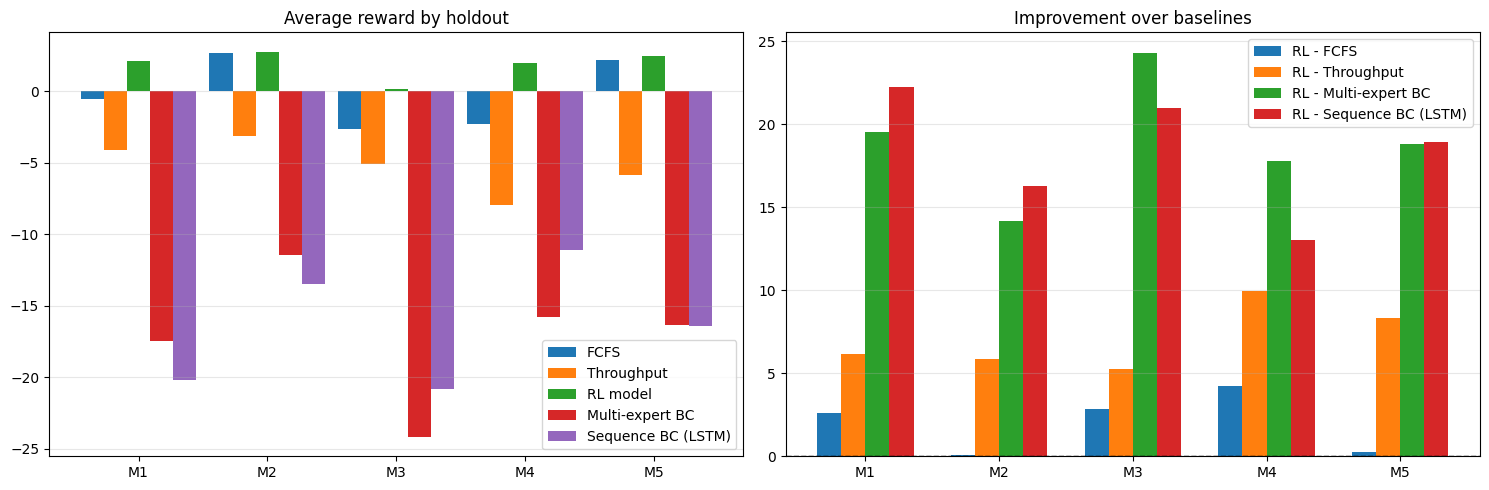

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model_name,model_path,held_out_municipality,episodes,rl_avg_reward,rl_reward_std,fcfs_avg_reward,fcfs_reward_std,throughput_avg_reward,throughput_reward_std,rl_minus_fcfs,rl_minus_throughput,multi_expert_bc_avg_reward,sequence_bc_lstm_avg_reward,rl_minus_multi_expert_bc,rl_minus_sequence_bc_lstm
0,holdout_M1_selection_chunk005_ts286720.zip,output/trained_models/holdout_M1_selection_chu...,1,12,2.086836,0.740867,-0.533444,8.351423,-4.083484,12.491758,2.620280,6.170320,-17.477387,-20.196332,19.564223,22.283168
1,holdout_M2_selection_chunk005_ts286720.zip,output/trained_models/holdout_M2_selection_chu...,2,12,2.763938,0.784817,2.690678,0.915019,-3.124881,10.907180,0.073261,5.888820,-11.443906,-13.508320,14.207844,16.272259
2,holdout_M3_selection_chunk001_ts57344.zip,output/trained_models/holdout_M3_selection_chu...,3,12,0.142338,5.629962,-2.680450,14.750556,-5.102024,9.728529,2.822788,5.244362,-24.188724,-20.822598,24.331062,20.964936
3,holdout_M4_selection_chunk006_ts303104.zip,output/trained_models/holdout_M4_selection_chu...,4,12,1.970709,0.914967,-2.280760,12.884343,-7.981485,18.093110,4.251469,9.952195,-15.823071,-11.085383,17.793780,13.056092
4,holdout_M5_selection_chunk006_ts303104.zip,output/trained_models/holdout_M5_selection_chu...,5,12,2.469642,0.918529,2.200360,0.858718,-5.858361,23.652844,0.269282,8.328003,-16.332390,-16.457120,18.802032,18.926762


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
if 'comparison_df' not in globals() or comparison_df is None or len(comparison_df) == 0:
    p = OUTPUT_DIR / 'trained_model_comparison_fcfs_throughput.csv'
    if p.exists():
        comparison_df = pd.read_csv(p)
    else:
        raise FileNotFoundError(f'Comparison CSV not found: {p}')

plot_df = comparison_df.copy()

# Optional baseline files (auto-merge if available)
bc_multi_path = OUTPUT_DIR / 'multi_expert_bc_eval.csv'
bc_lstm_path = OUTPUT_DIR / 'sequence_bc_lstm_eval.csv'

if bc_multi_path.exists():
    bc_multi_df = pd.read_csv(bc_multi_path)
    needed = {'held_out_municipality', 'multi_expert_bc_avg_reward'}
    if needed.issubset(set(bc_multi_df.columns)):
        plot_df = plot_df.merge(
            bc_multi_df[['held_out_municipality', 'multi_expert_bc_avg_reward']],
            on='held_out_municipality',
            how='left'
        )
    else:
        print(f'Skipping {bc_multi_path.name}: missing required columns {needed}')
else:
    print('Optional baseline not found: multi_expert_bc_eval.csv')

if bc_lstm_path.exists():
    bc_lstm_df = pd.read_csv(bc_lstm_path)
    needed = {'held_out_municipality', 'sequence_bc_lstm_avg_reward'}
    if needed.issubset(set(bc_lstm_df.columns)):
        plot_df = plot_df.merge(
            bc_lstm_df[['held_out_municipality', 'sequence_bc_lstm_avg_reward']],
            on='held_out_municipality',
            how='left'
        )
    else:
        print(f'Skipping {bc_lstm_path.name}: missing required columns {needed}')
else:
    print('Optional baseline not found: sequence_bc_lstm_eval.csv')

# Compute RL gaps for optional baselines (if available)
if 'multi_expert_bc_avg_reward' in plot_df.columns:
    plot_df['rl_minus_multi_expert_bc'] = plot_df['rl_avg_reward'] - plot_df['multi_expert_bc_avg_reward']
if 'sequence_bc_lstm_avg_reward' in plot_df.columns:
    plot_df['rl_minus_sequence_bc_lstm'] = plot_df['rl_avg_reward'] - plot_df['sequence_bc_lstm_avg_reward']

labels = [f"M{m}" for m in plot_df['held_out_municipality'].tolist()]
x = np.arange(len(labels))

# -----------------------------
# Chart 1: average reward bars
# -----------------------------
reward_series = [
    ('FCFS', plot_df['fcfs_avg_reward']),
    ('Throughput', plot_df['throughput_avg_reward']),
    ('Deepest-step', plot_df['deepest_step_avg_reward']),
    ('Adaptive-queue', plot_df['adaptive_queue_avg_reward']),
    ('RL model', plot_df['rl_avg_reward']),
]
if 'multi_expert_bc_avg_reward' in plot_df.columns:
    reward_series.append(('Multi-expert BC', plot_df['multi_expert_bc_avg_reward']))
if 'sequence_bc_lstm_avg_reward' in plot_df.columns:
    reward_series.append(('Sequence BC (LSTM)', plot_df['sequence_bc_lstm_avg_reward']))

n_reward = len(reward_series)
w = min(0.18, 0.9 / max(n_reward, 1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
center_offset = (n_reward - 1) / 2.0
for idx, (name, vals) in enumerate(reward_series):
    axes[0].bar(x + (idx - center_offset) * w, vals, width=w, label=name)

axes[0].set_title('Average reward by holdout')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend()

# -----------------------------------
# Chart 2: RL improvement over baselines
# -----------------------------------
gap_series = [
    ('RL - FCFS', plot_df['rl_minus_fcfs']),
    ('RL - Throughput', plot_df['rl_minus_throughput']),
    ('RL - Deepest-step', plot_df['rl_minus_deepest_step']),
    ('RL - Adaptive-queue', plot_df['rl_minus_adaptive_queue']),
]
if 'rl_minus_multi_expert_bc' in plot_df.columns:
    gap_series.append(('RL - Multi-expert BC', plot_df['rl_minus_multi_expert_bc']))
if 'rl_minus_sequence_bc_lstm' in plot_df.columns:
    gap_series.append(('RL - Sequence BC (LSTM)', plot_df['rl_minus_sequence_bc_lstm']))

n_gap = len(gap_series)
wg = min(0.18, 0.9 / max(n_gap, 1))
center_offset_g = (n_gap - 1) / 2.0
for idx, (name, vals) in enumerate(gap_series):
    axes[1].bar(x + (idx - center_offset_g) * wg, vals, width=wg, label=name)

axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Improvement over baselines')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()

plt.tight_layout()
plt.show()

display(plot_df)

summary_cols = [
    'held_out_municipality',
    'rl_minus_fcfs', 'rl_vs_fcfs_ci95', 'rl_vs_fcfs_win_rate',
    'rl_minus_throughput', 'rl_vs_throughput_ci95', 'rl_vs_throughput_win_rate',
    'rl_minus_deepest_step', 'rl_vs_deepest_step_ci95', 'rl_vs_deepest_step_win_rate',
    'rl_minus_adaptive_queue', 'rl_vs_adaptive_queue_ci95', 'rl_vs_adaptive_queue_win_rate',
]
available_summary_cols = [c for c in summary_cols if c in plot_df.columns]
if len(available_summary_cols) > 1:
    print('Paired reward-gap summary (mean gap ±95% CI and RL win-rate):')
    display(plot_df[available_summary_cols])